# Module B: Hierarchical Planning (B1-B6)

**Demo-Guided Subgoal Extraction + Subgoal Predictor + Hierarchical CEM Planner**

| # | Task | Detail |
|---|------|--------|
| B1 | Subgoal extraction | Gripper transitions + velocity peaks + min_gap=10 |
| B2 | Subgoal visualization | Plot 3-5 episodes with subgoal annotations |
| B3 | Subgoal predictor | MLP + 2-layer Transformer, ablate W_G={1,2,3} |
| B4 | Hierarchical CEM planner | Subgoal predict -> short-horizon CEM -> execute -> repeat |
| B5 | Flat vs Hierarchical CEM | Goal cosine similarity, Success@K |
| B6 | Hierarchical CEM ablations | h={5,10}, subgoal predictor type, budget-matched |

**Prerequisites**: Module A predictor checkpoints at `outputs/module_a_transformer_K{K}_T8.pt`.

## Section 1: Setup & Imports

In [ ]:
import sys, subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['torch>=2.0', 'matplotlib', 'scikit-learn', 'tqdm', 'numpy', 'pandas', 'scipy', 'pyarrow']:
    pip_install(pkg)

import os, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.signal import argrelextrema

# Paths (Colab-aware)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/jepa_action')
    print('Mounted Google Drive. Make sure data/ is at MyDrive/jepa_action/data/')
except ImportError:
    ROOT = Path(os.getcwd()).resolve()
    if not (ROOT / 'data' / 'embeddings').exists():
        if (ROOT.parent / 'data' / 'embeddings').exists():
            ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
EMBED_DIR = DATA_DIR / 'embeddings'
PARQUET_DIR = DATA_DIR / 'robomimic-ph-lift-image' / 'data' / 'chunk-000'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Config
class Config:
    embed_dim = 384
    action_dim = 7
    d_model = 256
    n_heads = 4
    n_layers_tr = 4
    n_layers_sg = 2
    batch_size = 1024      # Colab L4: 24GB VRAM
    lr = 1e-4
    weight_decay = 0.05
    warmup_steps = 200
    max_epochs = 30
    use_amp = True
    dropout_p = 0.2
    sg_dropout = 0.1
    sg_hidden = [256, 128]
    seed = 42
    K_values = [1, 5, 10, 20]
    best_T = 8
    WG_values = [1, 2, 3]
    min_gap = 10
    cem_n_pop = 128
    cem_elite_frac = 0.1
    cem_n_iters = 5
    flat_H_values = [20, 40]
    hier_h_values = [5, 10]
    success_threshold = 0.90
    n_train_episodes = 160

cfg = Config()

# Device & reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    # gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    # print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(cfg.seed)
    torch.backends.cudnn.benchmark = True

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive. Make sure data/ is at MyDrive/jepa_action/data/
Device: cuda
Setup complete.


## Section 2: Load Cached Embeddings + Per-Episode Parquet Data

Load pre-computed embeddings/actions, then read all 200 Parquet files to extract per-episode gripper states. The embedding cache uses a **160/40 chronological train/val split** (first 160 episodes = train, remaining 40 = val).

In [ ]:
# Load cached embeddings and actions
train_emb = torch.load(EMBED_DIR / 'embeddings_train.pt').float()
val_emb = torch.load(EMBED_DIR / 'embeddings_val.pt').float()
train_act = torch.load(EMBED_DIR / 'actions_train.pt').float()
val_act = torch.load(EMBED_DIR / 'actions_val.pt').float()
norm_stats = torch.load(EMBED_DIR / 'norm_stats.pt')

print(f'Train embeddings: {train_emb.shape}')
print(f'Val embeddings:   {val_emb.shape}')
print(f'Train actions:     {train_act.shape}')

mean_embed = train_emb.mean(dim=0, keepdim=True)

Train embeddings: torch.Size([3901, 384])
Val embeddings:   torch.Size([984, 384])
Train actions:     torch.Size([3901, 7])


In [ ]:
# Load all Parquet files (chronological order), extract per-episode data at 10Hz
parquet_files = sorted(PARQUET_DIR.glob('episode_*.parquet'))
print(f'Found {len(parquet_files)} parquet episodes')

all_ep_actions = []
all_ep_gripper = []
all_ep_n_frames = []

for pf in tqdm(parquet_files, desc='Loading parquets'):
    df = pd.read_parquet(pf)
    actions_raw = np.stack(df['action'].values).astype(np.float32)
    states_raw = np.stack(df['observation.state'].values).astype(np.float32)
    gripper_openness = states_raw[:, 7] - states_raw[:, 8]
    # Subsample from 20Hz to 10Hz
    all_ep_actions.append(torch.tensor(actions_raw[::2]))
    all_ep_gripper.append(torch.tensor(gripper_openness[::2]))
    all_ep_n_frames.append(len(actions_raw[::2]))

# Verify alignment: first 160 episodes = train, last 40 = val
train_frames_total = sum(all_ep_n_frames[:cfg.n_train_episodes])
val_frames_total = sum(all_ep_n_frames[cfg.n_train_episodes:])
print(f'\nFirst {cfg.n_train_episodes} episodes: {train_frames_total} 10Hz frames (emb: {train_emb.shape[0]})')
print(f'Last {len(parquet_files)-cfg.n_train_episodes} episodes: {val_frames_total} 10Hz frames (emb: {val_emb.shape[0]})')
assert train_frames_total == train_emb.shape[0], f'Train mismatch: {train_frames_total} vs {train_emb.shape[0]}'
assert val_frames_total == val_emb.shape[0], f'Val mismatch: {val_frames_total} vs {val_emb.shape[0]}'
print('Split verified.')

Found 200 parquet episodes


Loading parquets:   0%|          | 0/200 [00:00<?, ?it/s]


First 160 episodes: 3901 10Hz frames (emb: 3901)
Last 40 episodes: 984 10Hz frames (emb: 984)
Split verified.


In [ ]:
# Build episode-to-embedding-index mappings
# Train episodes 0..159 map sequentially into train_emb
# Val episodes 160..199 map sequentially into val_emb
train_offset = 0
val_offset = 0
ep_to_emb_start = {}

for ep_idx in range(len(parquet_files)):
    n_frames = all_ep_n_frames[ep_idx]
    if ep_idx < cfg.n_train_episodes:
        ep_to_emb_start[ep_idx] = ('train', train_offset)
        train_offset += n_frames
    else:
        ep_to_emb_start[ep_idx] = ('val', val_offset)
        val_offset += n_frames

def get_emb_idx(ep_idx, local_frame_idx):
    split, start = ep_to_emb_start[ep_idx]
    return split, start + local_frame_idx

print(f'Train offset range: 0-{train_offset}, Val offset range: 0-{val_offset}')
print('Episode mapping built and verified.')

Train offset range: 0-3901, Val offset range: 0-984
Episode mapping built and verified.


## Section 3: B1 - Subgoal Extraction

Implement `extract_subgoals()` using gripper state changes + action velocity peaks + `min_gap=10`. Run on all training episodes.

In [ ]:
def detect_gripper_transitions(gripper_openness, percentile=95):
    """Detect frames where gripper openness changes significantly."""
    if len(gripper_openness) < 2:
        return []
    g = gripper_openness.numpy() if isinstance(gripper_openness, torch.Tensor) else gripper_openness
    diffs = np.abs(np.diff(g))
    threshold = np.percentile(diffs, percentile)
    if threshold <= 0:
        return []
    change_frames = np.where(diffs > threshold)[0] + 1
    return sorted(change_frames.tolist())


def detect_velocity_peaks(actions, n_peaks=3):
    """Detect local maxima in action velocity magnitude."""
    a = actions.numpy() if isinstance(actions, torch.Tensor) else actions
    vel_mag = np.linalg.norm(a, axis=1)
    if len(vel_mag) < 3:
        return []
    peaks = argrelextrema(vel_mag, np.greater, order=2)[0]
    if len(peaks) == 0:
        return []
    if n_peaks is not None and len(peaks) > n_peaks:
        peak_vals = vel_mag[peaks]
        top_idx = np.argsort(peak_vals)[-n_peaks:]
        peaks = peaks[top_idx]
    return sorted(peaks.tolist())


def extract_subgoals(actions, gripper_openness, min_gap=10, percentile=95, n_peaks=3):
    """Extract subgoal frame indices for a single episode."""
    gripper_frames = detect_gripper_transitions(gripper_openness, percentile)
    vel_frames = detect_velocity_peaks(actions, n_peaks)
    candidates = sorted(set(gripper_frames + vel_frames))
    subgoals = []
    for idx in candidates:
        if not subgoals or (idx - subgoals[-1]) >= min_gap:
            subgoals.append(idx)
    return subgoals

print('Subgoal extraction functions defined.')

Subgoal extraction functions defined.


In [ ]:
# Run subgoal extraction on all training episodes
SUBGOALS_CACHE = EMBED_DIR / 'subgoals.pt'

if SUBGOALS_CACHE.exists():
    print('Loading cached subgoals...')
    d = torch.load(SUBGOALS_CACHE, weights_only=False)
    train_sg_local = d['train_sg_local']
    train_sg_embs = d['train_sg_embs']
else:
    print('Extracting subgoals for all training episodes...')
    train_sg_local = []
    train_sg_embs = []
    
    for ep in tqdm(range(cfg.n_train_episodes), desc='Train subgoals'):
        actions = all_ep_actions[ep]
        gripper = all_ep_gripper[ep]
        n_frames = all_ep_n_frames[ep]
        sg_local = extract_subgoals(actions, gripper, cfg.min_gap)
        if len(sg_local) == 0:
            sg_local = [n_frames // 2]
        train_sg_local.append(sg_local)
    
    for ep in range(cfg.n_train_episodes):
        sg_local_ep = train_sg_local[ep]
        _, start = ep_to_emb_start[ep]
        sg_embs_ep = train_emb[torch.tensor([start + idx for idx in sg_local_ep])]
        train_sg_embs.append(sg_embs_ep)
    
    torch.save({'train_sg_local': train_sg_local, 'train_sg_embs': train_sg_embs}, SUBGOALS_CACHE)
    print(f'Saved subgoals to {SUBGOALS_CACHE}')

sg_counts = [len(sg) for sg in train_sg_local]
print(f'\nB1 Results:')
print(f'  Episodes with subgoals: {sum(1 for c in sg_counts if c > 0)}/{cfg.n_train_episodes}')
print(f'  Total subgoals extracted: {sum(sg_counts)}')
print(f'  Mean subgoals per episode: {np.mean(sg_counts):.2f}')

Loading cached subgoals...

B1 Results:
  Episodes with subgoals: 160/160
  Total subgoals extracted: 324
  Mean subgoals per episode: 2.02


## Section 4: B2 - Subgoal Visualization

Plot 3-5 episodes with 2 subplots each: gripper openness and action magnitude, with subgoal markers.

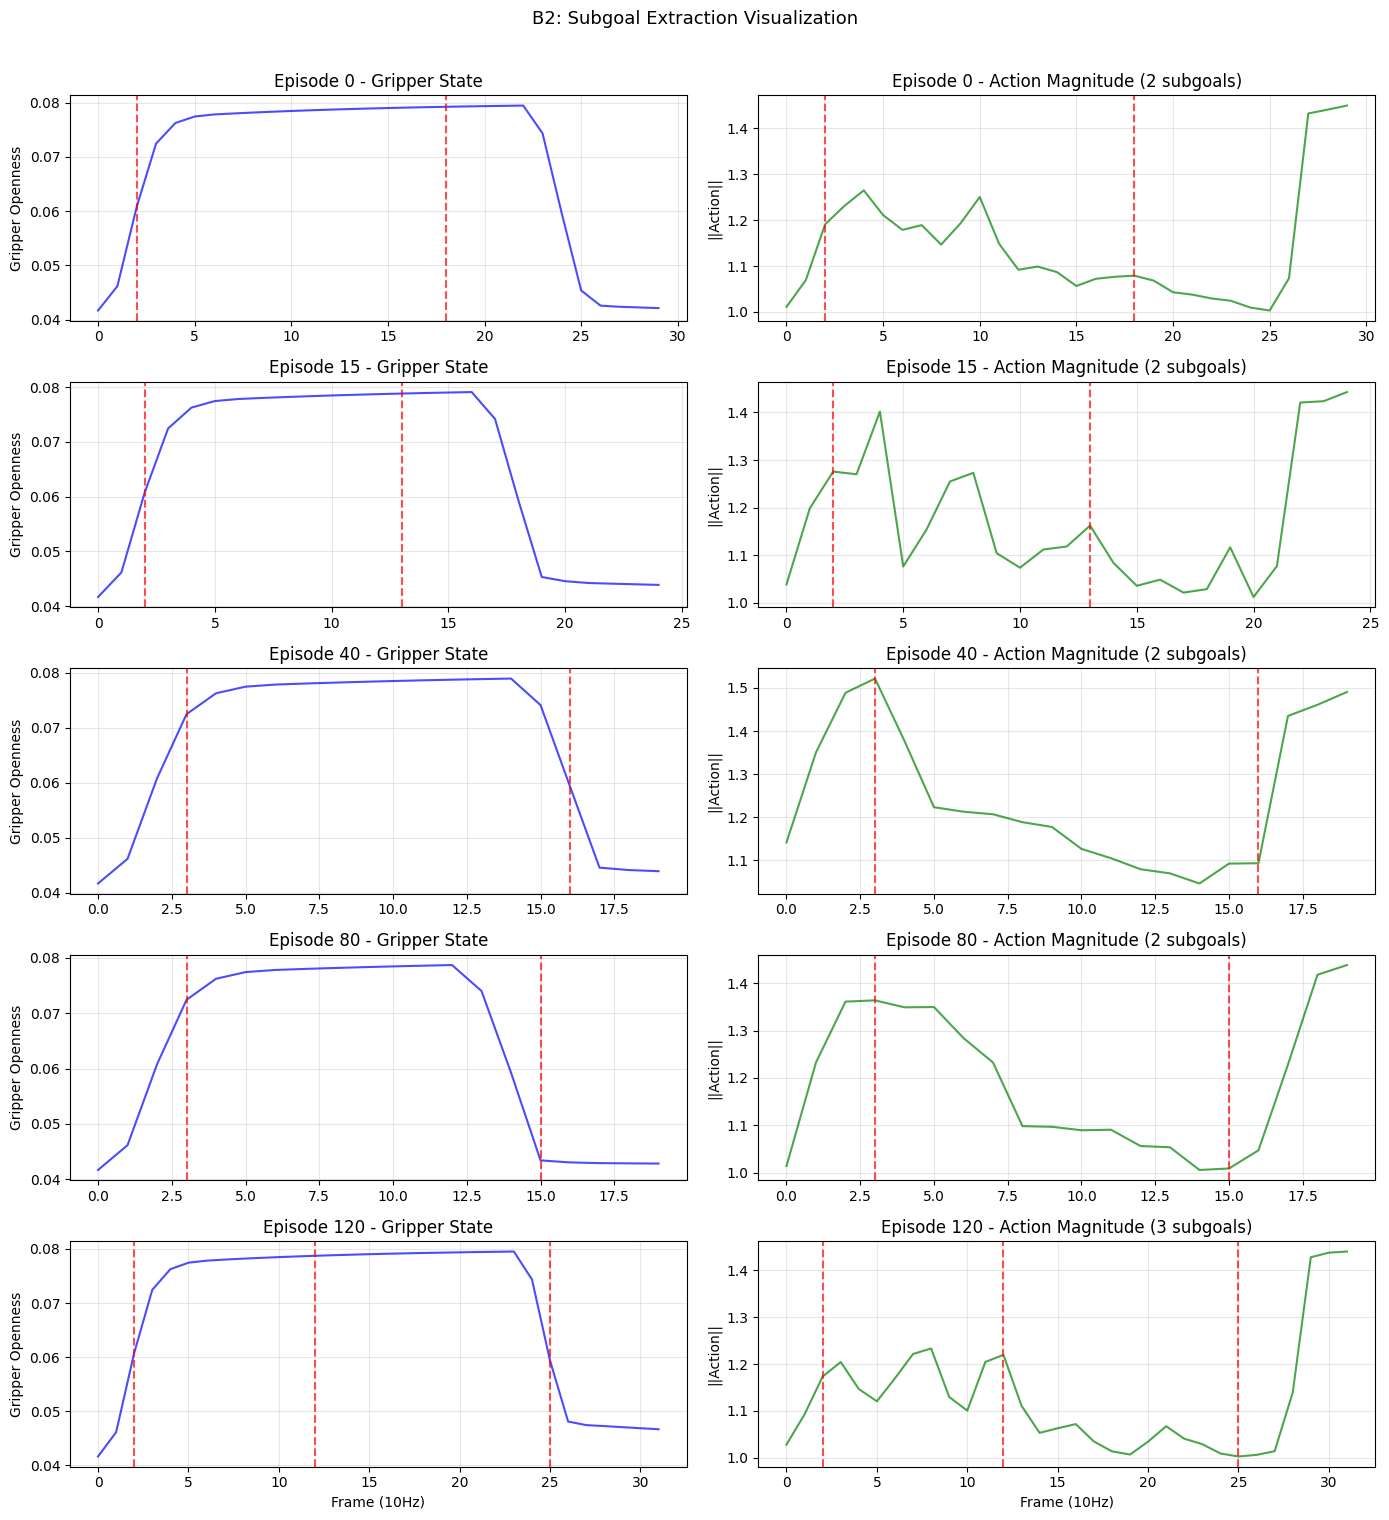

In [ ]:
n_viz = min(5, cfg.n_train_episodes)
viz_eps = [0, 15, 40, 80, 120][:n_viz]

fig, axes = plt.subplots(n_viz, 2, figsize=(14, 3 * n_viz))
if n_viz == 1:
    axes = axes.reshape(1, -1)

for i, ep in enumerate(viz_eps):
    actions = all_ep_actions[ep].numpy()
    gripper = all_ep_gripper[ep].numpy()
    sg = train_sg_local[ep]
    vel_mag = np.linalg.norm(actions, axis=1)
    frames = np.arange(len(actions))
    
    ax = axes[i, 0]
    ax.plot(frames, gripper, 'b-', linewidth=1.5, alpha=0.7)
    for s in sg:
        ax.axvline(x=s, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_ylabel('Gripper Openness')
    if i == n_viz - 1:
        ax.set_xlabel('Frame (10Hz)')
    ax.set_title(f'Episode {ep} - Gripper State')
    ax.grid(True, alpha=0.3)
    
    ax = axes[i, 1]
    ax.plot(frames, vel_mag, 'g-', linewidth=1.5, alpha=0.7)
    for s in sg:
        ax.axvline(x=s, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_ylabel('||Action||')
    if i == n_viz - 1:
        ax.set_xlabel('Frame (10Hz)')
    ax.set_title(f'Episode {ep} - Action Magnitude ({len(sg)} subgoals)')
    ax.grid(True, alpha=0.3)

fig.suptitle('B2: Subgoal Extraction Visualization', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b2_subgoal_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: B3 - Subgoal Predictor

Train MLP and 2-layer Transformer subgoal predictors. Ablate context window W_G in {1, 2, 3}.

In [ ]:
class SubgoalDataset(Dataset):
    def __init__(self, subgoal_embeddings_list, WG=2):
        self.samples = []
        for sg_embs in subgoal_embeddings_list:
            M = sg_embs.shape[0]
            for i in range(WG, M):
                context = sg_embs[i - WG:i].flatten()
                target = sg_embs[i]
                self.samples.append((context, target))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class MLPSubgoalPredictor(nn.Module):
    def __init__(self, input_dim, embed_dim=384, hidden=[256, 128]):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        layers.append(nn.Linear(in_dim, embed_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


class TransformerSubgoalPredictor(nn.Module):
    def __init__(self, embed_dim=384, d_model=256, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed_dim = embed_dim
        self.embed_proj = nn.Linear(embed_dim, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, 10, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, batch_first=True,
            dropout=dropout, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.predictor = nn.Linear(d_model, embed_dim)
    
    def forward(self, x):
        B, D = x.shape
        WG = D // self.embed_dim
        x = x.view(B, WG, self.embed_dim)
        x = self.embed_proj(x) + self.pos_embed[:, :WG, :]
        x = self.transformer(x)
        return self.predictor(x[:, -1, :])

print(f'MLP params (WG=1): {sum(p.numel() for p in MLPSubgoalPredictor(384).parameters()):,}')
print(f'Transformer params: {sum(p.numel() for p in TransformerSubgoalPredictor().parameters()):,}')

MLP params (WG=1): 180,992
Transformer params: 2,829,952


In [ ]:
# Training utilities
def cosine_loss(pred, target):
    return 1.0 - F.cosine_similarity(pred, target, dim=-1).mean()

def get_lr(step, warmup_steps, total_steps, base_lr):
    if step < warmup_steps:
        return base_lr * step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

@torch.no_grad()
def compute_val_cosine(model, loader):
    model.eval()
    cs_list = []
    for ctx, target in loader:
        ctx, target = ctx.to(device), target.to(device)
        if cfg.use_amp and device.type == 'cuda':
            with autocast():
                pred = model(ctx)
        else:
            pred = model(ctx)
        cs = F.cosine_similarity(pred, target, dim=-1).mean().item()
        cs_list.append(cs)
    return np.mean(cs_list)

def train_sg_model(model, train_loader, val_loader, epochs=30, verbose=False):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler = GradScaler(enabled=(cfg.use_amp and device.type == 'cuda'))
    total_steps = epochs * len(train_loader)
    gs = 0
    train_losses, val_cos_list = [], []
    best_cos = -1.0
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for ctx, target in train_loader:
            ctx, target = ctx.to(device), target.to(device)
            lr = get_lr(gs, cfg.warmup_steps, total_steps, cfg.lr)
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            if cfg.use_amp and device.type == 'cuda':
                with autocast():
                    pred = model(ctx)
                    loss = cosine_loss(pred, target)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                pred = model(ctx)
                loss = cosine_loss(pred, target)
                loss.backward()
                optimizer.step()
            optimizer.zero_grad()
            epoch_loss += loss.item()
            gs += 1
        
        val_cos = compute_val_cosine(model, val_loader)
        train_losses.append(epoch_loss / len(train_loader))
        val_cos_list.append(val_cos)
        if val_cos > best_cos:
            best_cos = val_cos
        if verbose or epoch % max(1, epochs // 5) == 0 or epoch == 1 or epoch == epochs:
            print(f'E {epoch:3d}/{epochs} | loss={train_losses[-1]:.4f} | val_cos={val_cos:.4f} | best={best_cos:.4f}')
    
    return {'val_cos': val_cos, 'best_cos': best_cos,
            'train_losses': train_losses, 'val_cos_list': val_cos_list}

print('Training utilities ready.')

Training utilities ready.


In [ ]:
# Build train/val split for subgoal predictor (80/20 of train episodes)
n_sg_train = int(len(train_sg_embs) * 0.8)
sg_embs_tr = train_sg_embs[:n_sg_train]
sg_embs_val = train_sg_embs[n_sg_train:]

print(f'SG train episodes: {n_sg_train}, SG val episodes: {len(train_sg_embs) - n_sg_train}')
print(f'Total subgoals in train: {sum(len(s) for s in sg_embs_tr)}, val: {sum(len(s) for s in sg_embs_val)}')

SG train episodes: 128, SG val episodes: 32
Total subgoals in train: 260, val: 64


In [ ]:
# Train all subgoal predictors
sg_results = {}

for arch_name, make_fn in [
    ('MLP', lambda d: MLPSubgoalPredictor(d, cfg.embed_dim, cfg.sg_hidden)),
    ('Transf', lambda d: TransformerSubgoalPredictor(cfg.embed_dim, cfg.d_model, cfg.n_heads, cfg.n_layers_sg, cfg.sg_dropout)),
]:
    for WG in cfg.WG_values:
        key = f'{arch_name}_WG{WG}'
        ckpt_path = OUTPUT_DIR / f'b3_{key}.pt'
        
        if ckpt_path.exists():
            print(f'[CACHED] {key}')
            d = torch.load(ckpt_path, map_location=device, weights_only=False)
            sg_results[key] = d
            continue
        
        print(f'\n{"="*55}')
        print(f'Training {arch_name}, WG={WG}')
        print(f'{"="*55}')
        
        input_dim = WG * cfg.embed_dim
        train_ds = SubgoalDataset(sg_embs_tr, WG)
        val_ds = SubgoalDataset(sg_embs_val, WG)
        
        if len(train_ds) == 0:
            print(f'  WARNING: No samples for WG={WG}, skipping.')
            continue
        
        train_ldr = DataLoader(train_ds, batch_size=min(1024, len(train_ds)), shuffle=True,
                                num_workers=4, pin_memory=(device.type=='cuda'), drop_last=True)
        val_ldr = DataLoader(val_ds, batch_size=1024, shuffle=False,
                              num_workers=4, pin_memory=(device.type=='cuda'))
        
        model = make_fn(input_dim).to(device)
        result = train_sg_model(model, train_ldr, val_ldr, cfg.max_epochs, verbose=True)
        
        torch.save({
            'model_state_dict': model.state_dict(),
            'val_cos': result['val_cos'],
            'best_cos': result['best_cos'],
            'val_cos_list': result['val_cos_list'],
            'WG': WG,
            'arch': arch_name,
        }, ckpt_path)
        
        sg_results[key] = {
            'val_cos': result['val_cos'], 'best_cos': result['best_cos'],
            'val_cos_list': result['val_cos_list'], 'WG': WG, 'arch': arch_name,
        }

print('\nSubgoal predictor training complete.')


Training MLP, WG=1


/tmp/ipykernel_50601/3024729224.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(cfg.use_amp and device.type == 'cuda'))
/tmp/ipykernel_50601/3024729224.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   1/30 | loss=1.0306 | val_cos=-0.0181 | best=-0.0181


/tmp/ipykernel_50601/3024729224.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   2/30 | loss=1.0306 | val_cos=-0.0180 | best=-0.0180
E   3/30 | loss=1.0304 | val_cos=-0.0176 | best=-0.0176
E   4/30 | loss=1.0301 | val_cos=-0.0172 | best=-0.0172
E   5/30 | loss=1.0296 | val_cos=-0.0165 | best=-0.0165
E   6/30 | loss=1.0290 | val_cos=-0.0157 | best=-0.0157
E   7/30 | loss=1.0281 | val_cos=-0.0147 | best=-0.0147
E   8/30 | loss=1.0272 | val_cos=-0.0136 | best=-0.0136
E   9/30 | loss=1.0260 | val_cos=-0.0123 | best=-0.0123
E  10/30 | loss=1.0247 | val_cos=-0.0108 | best=-0.0108
E  11/30 | loss=1.0233 | val_cos=-0.0092 | best=-0.0092
E  12/30 | loss=1.0217 | val_cos=-0.0074 | best=-0.0074
E  13/30 | loss=1.0199 | val_cos=-0.0055 | best=-0.0055
E  14/30 | loss=1.0179 | val_cos=-0.0033 | best=-0.0033
E  15/30 | loss=1.0158 | val_cos=-0.0011 | best=-0.0011
E  16/30 | loss=1.0135 | val_cos=0.0014 | best=0.0014
E  17/30 | loss=1.0111 | val_cos=0.0040 | best=0.0040
E  18/30 | loss=1.0085 | val_cos=0.0068 | best=0.0068
E  19/30 | loss=1.0057 | val_cos=0.0097 | best=0.0097


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


E   2/30 | loss=1.0317 | val_cos=nan | best=-1.0000
E   3/30 | loss=1.0315 | val_cos=nan | best=-1.0000
E   4/30 | loss=1.0309 | val_cos=nan | best=-1.0000
E   5/30 | loss=1.0301 | val_cos=nan | best=-1.0000
E   6/30 | loss=1.0290 | val_cos=nan | best=-1.0000
E   7/30 | loss=1.0276 | val_cos=nan | best=-1.0000
E   8/30 | loss=1.0259 | val_cos=nan | best=-1.0000
E   9/30 | loss=1.0240 | val_cos=nan | best=-1.0000
E  10/30 | loss=1.0218 | val_cos=nan | best=-1.0000
E  11/30 | loss=1.0193 | val_cos=nan | best=-1.0000
E  12/30 | loss=1.0166 | val_cos=nan | best=-1.0000
E  13/30 | loss=1.0135 | val_cos=nan | best=-1.0000
E  14/30 | loss=1.0103 | val_cos=nan | best=-1.0000
E  15/30 | loss=1.0068 | val_cos=nan | best=-1.0000
E  16/30 | loss=1.0030 | val_cos=nan | best=-1.0000
E  17/30 | loss=0.9989 | val_cos=nan | best=-1.0000
E  18/30 | loss=0.9946 | val_cos=nan | best=-1.0000
E  19/30 | loss=0.9899 | val_cos=nan | best=-1.0000
E  20/30 | loss=0.9851 | val_cos=nan | best=-1.0000
E  21/30 | l

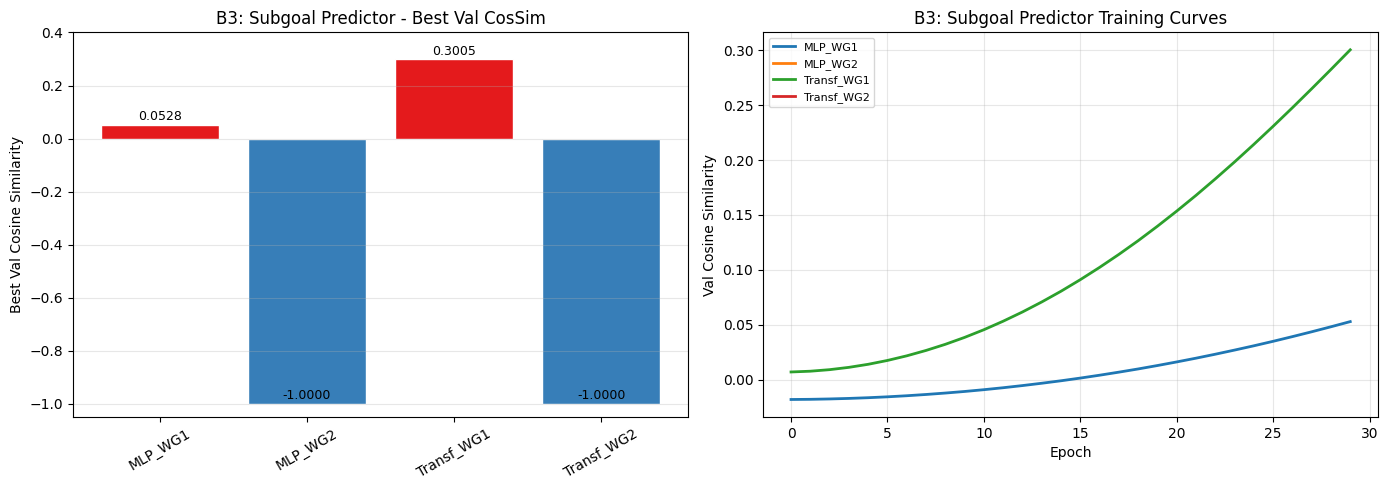


Arch    WG    Best CosSim   Final CosSim  
------------------------------------------
MLP     1     0.0528        0.0528        
MLP     2     -1.0000       nan           
Transf  1     0.3005        0.3005        
Transf  2     -1.0000       nan           


In [ ]:
# Plot B3: Subgoal Predictor Ablation Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sorted_keys = sorted(sg_results.keys())
cos_vals = [sg_results[k]['best_cos'] for k in sorted_keys]
colors_wg = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a'}
bar_colors = [colors_wg[sg_results[k]['WG']] for k in sorted_keys]

bars = ax.bar(sorted_keys, cos_vals, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, cos_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Best Val Cosine Similarity')
ax.set_title('B3: Subgoal Predictor - Best Val CosSim')
lo = min(cos_vals) - 0.05
ax.set_ylim(lo, max(cos_vals) + 0.1)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
for k in sorted_keys:
    if 'val_cos_list' in sg_results[k]:
        ax.plot(sg_results[k]['val_cos_list'], linewidth=2, label=k)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title('B3: Subgoal Predictor Training Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b3_subgoal_predictor.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Arch":<8}{"WG":<6}{"Best CosSim":<14}{"Final CosSim":<14}')
print('-' * 42)
for k in sorted_keys:
    r = sg_results[k]
    print(f'{r["arch"]:<8}{r["WG"]:<6}{r["best_cos"]:<14.4f}{r["val_cos"]:<14.4f}')

## Section 6: B4 - Hierarchical CEM Planner

Re-define Transformer predictor locally, load Module A checkpoints, implement CEM planners.

In [ ]:
# Re-define Transformer predictor (same as Module A)
class ActionMLP(nn.Module):
    def __init__(self, action_dim=7, hidden_dim=128, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(action_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, a):
        return self.net(a)

class TransformerPredictor(nn.Module):
    def __init__(self, embed_dim=384, action_dim=7, d_model=256,
                 n_layers=4, n_heads=4, max_seq_len=64, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.embed_proj = nn.Linear(embed_dim, d_model)
        self.action_mlp = ActionMLP(action_dim, hidden_dim=128, out_dim=d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, batch_first=True,
            dropout=dropout, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.predictor = nn.Linear(d_model, embed_dim)

    def forward(self, embeds, actions):
        if embeds.dim() == 2:
            embeds = embeds.unsqueeze(1); actions = actions.unsqueeze(1)
        B, T, _ = embeds.shape
        x = self.embed_proj(embeds) + self.action_mlp(actions)
        x = x + self.pos_embed[:, :T, :]
        causal_mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        x = self.transformer(x, mask=causal_mask)
        return self.predictor(x[:, -1, :])

# Load all predictors
jepa_predictors = {}
for K in cfg.K_values:
    ckpt_path = OUTPUT_DIR / f'module_a_transformer_K{K}_T{cfg.best_T}.pt'
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = TransformerPredictor(
        embed_dim=cfg.embed_dim, action_dim=cfg.action_dim, d_model=cfg.d_model,
        n_layers=cfg.n_layers_tr, n_heads=cfg.n_heads, dropout=cfg.dropout_p,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    jepa_predictors[K] = model
    print(f'Loaded JEPA predictor K={K} (T={cfg.best_T})')

Loaded JEPA predictor K=1 (T=8)
Loaded JEPA predictor K=5 (T=8)
Loaded JEPA predictor K=10 (T=8)
Loaded JEPA predictor K=20 (T=8)


In [ ]:
@torch.no_grad()
def cem_plan(z_start, z_target, predictor, horizon, K, T,
             n_pop=128, elite_frac=0.1, n_iters=5, noise_scale=0.5,
             action_dim=7, verbose=False, z_secondary=None, alpha=1.0):
    """CEM planning in embedding space.
    horizon: number of CEM steps (each covers K physical frames via one predictor call)."""
    n_elite = max(1, int(n_pop * elite_frac))
    mu = torch.zeros(horizon, action_dim, device=device)
    sigma = torch.ones(horizon, action_dim, device=device) * noise_scale
    best_seq, best_score = None, -float('inf')
    
    for it in range(n_iters):
        eps = torch.randn(n_pop, horizon, action_dim, device=device)
        actions = mu.unsqueeze(0) + sigma.unsqueeze(0) * eps
        scores = torch.zeros(n_pop, device=device)
        
        for i in range(n_pop):
            z_ctx = z_start.clone().unsqueeze(0).unsqueeze(0).repeat(1, T, 1)
            a_ctx = torch.zeros(1, T, action_dim, device=device)
            a_ctx[:, -1, :] = actions[i, 0]
            for step in range(horizon):
                a_cur = actions[i, step:step+1].unsqueeze(0)
                a_ctx = torch.cat([a_ctx[:, 1:, :], a_cur], dim=1)
                pred = predictor(z_ctx, a_ctx)
                z_ctx = torch.cat([z_ctx[:, 1:, :], pred.unsqueeze(1)], dim=1)
            z_pred = z_ctx[:, -1, :].squeeze(0)
            cos_goal = F.cosine_similarity(z_pred.unsqueeze(0), z_target.unsqueeze(0), dim=-1)
            if z_secondary is not None:
                cos_secondary = F.cosine_similarity(z_pred.unsqueeze(0), z_secondary.unsqueeze(0), dim=-1)
                scores[i] = alpha * cos_goal + (1 - alpha) * cos_secondary
            else:
                scores[i] = cos_goal
        
        elite_idx = torch.topk(scores, n_elite).indices
        ea = actions[elite_idx]
        mu = ea.mean(dim=0)
        sigma = ea.std(dim=0) + 1e-6
        
        iter_best = scores[elite_idx[0]].item()
        if iter_best > best_score:
            best_score = iter_best
            best_seq = ea[0].cpu().numpy()
        if verbose:
            print(f'  CEM iter {it+1}/{n_iters}: best={iter_best:.4f}')
    
    return best_seq, best_score


@torch.no_grad()
def flat_cem_plan(z_start, z_goal, predictor, H, K, T, **kw):
    """Flat CEM: plan H physical frames (horizon = H // K)."""
    horizon = max(1, H // K)
    return cem_plan(z_start, z_goal, predictor, horizon, K, T, **kw)


@torch.no_grad()
def hierarchical_cem_plan(z_start, sg_model, jepa_pred, h, K, T,
                          n_cycles=10, budget_matched=False, H_flat=None,
                          z_goal=None, alpha_start=0.5, alpha_end=0.95,
                          early_stop_thresh=0.95, **kw):
    """Hierarchical CEM: subgoal predict -> short CEM -> simulate -> repeat."""
    WG = getattr(sg_model, 'WG', 2)
    z_cur = z_start.clone()
    past_sgs = [z_cur.cpu().numpy()]
    
    for cycle in range(n_cycles):
        while len(past_sgs) < WG:
            past_sgs.append(past_sgs[-1])
        ctx = torch.tensor(np.concatenate(past_sgs[-WG:])).float().unsqueeze(0).to(device)
        z_sg = sg_model(ctx).squeeze(0)
        
        h_actual = h
        if budget_matched and H_flat is not None:
            h_actual = max(1, int(np.ceil(H_flat / K / n_cycles)))
        
        # Compute cycle-varying alpha: earlier cycles weight subgoals more
        progress = cycle / max(1, n_cycles - 1)
        alpha = alpha_start + (alpha_end - alpha_start) * progress
        
        z_secondary = z_goal if z_goal is not None else None
        actions, score = cem_plan(z_cur, z_sg, jepa_pred, h_actual, K, T,
                                  z_secondary=z_secondary, alpha=alpha, **kw)
        
        # Simulate forward
        z_ctx = z_cur.unsqueeze(0).unsqueeze(0).repeat(1, T, 1)
        a_ctx = torch.zeros(1, T, cfg.action_dim, device=device)
        a_ctx[:, -1, :] = torch.tensor(actions[0]).float().to(device)
        for step in range(h_actual):
            a_cur = torch.tensor(actions[step:step+1]).float().unsqueeze(0).to(device)
            a_ctx = torch.cat([a_ctx[:, 1:, :], a_cur], dim=1)
            pred = jepa_pred(z_ctx, a_ctx)
            z_ctx = torch.cat([z_ctx[:, 1:, :], pred.unsqueeze(1)], dim=1)
            z_cur = pred.squeeze(0)
        
        past_sgs.append(z_sg.cpu().numpy())
        
        # Early stopping: break if close enough to final goal
        if z_goal is not None:
            cur_cos = F.cosine_similarity(z_cur.unsqueeze(0), z_goal.unsqueeze(0), dim=-1).item()
            if cur_cos >= early_stop_thresh:
                break
    
    return z_cur

print('CEM planners defined.')

CEM planners defined.


## Section 7: B5 - Flat vs Hierarchical CEM Evaluation

Evaluate on validation episodes. Metrics: Goal Cosine Similarity, Success Rate.

In [ ]:
# Pick best subgoal predictor
best_sg_key = max(sg_results, key=lambda k: sg_results[k]['best_cos'])
print(f'Best subgoal predictor: {best_sg_key} (best_cos={sg_results[best_sg_key]["best_cos"]:.4f})')

# Build eval samples from val episodes (episodes 160..199)
val_ep_indices = list(range(cfg.n_train_episodes, len(parquet_files)))
eval_samples = []
for ep in val_ep_indices:
    n_frames = all_ep_n_frames[ep]
    if n_frames < 3:
        continue
    _, start = ep_to_emb_start[ep]
    z_s = val_emb[start]
    z_g = val_emb[start + n_frames - 1]
    eval_samples.append({'ep': ep, 'z_start': z_s, 'z_goal': z_g, 'n_frames': n_frames})

print(f'Eval samples: {len(eval_samples)} val episodes')

Best subgoal predictor: Transf_WG1 (best_cos=0.3005)
Eval samples: 40 val episodes


In [ ]:
# Evaluate Flat CEM
FLAT_EVAL_CACHE = EMBED_DIR / 'flat_cem_eval.pt'

if FLAT_EVAL_CACHE.exists():
    print('Loading cached flat CEM results...')
    flat_cem_results = torch.load(FLAT_EVAL_CACHE, weights_only=False)
else:
    flat_cem_results = {}
    for K in cfg.K_values:
        predictor = jepa_predictors[K]
        for H in cfg.flat_H_values:
            horizon = max(1, H // K)
            key = f'flat_K{K}_H{H}'
            print(f'\nFlat CEM: K={K}, H={H} (horizon={horizon})')
            goal_cos_list, success_list = [], []
            for sample in tqdm(eval_samples, desc=f'Flat K={K} H={H}'):
                z_s, z_g = sample['z_start'].to(device), sample['z_goal'].to(device)
                _, score = cem_plan(z_s, z_g, predictor, horizon, K, cfg.best_T,
                                   cfg.cem_n_pop, cfg.cem_elite_frac, cfg.cem_n_iters)
                goal_cos_list.append(score)
                success_list.append(1.0 if score >= cfg.success_threshold else 0.0)
            flat_cem_results[key] = {
                'goal_cos': np.mean(goal_cos_list),
                'success_rate': np.mean(success_list),
            }
            print(f'  Goal cos={flat_cem_results[key]["goal_cos"]:.4f}, Success@{cfg.success_threshold:.2f}={flat_cem_results[key]["success_rate"]:.3f}')
    torch.save(flat_cem_results, FLAT_EVAL_CACHE)

print('\nFlat CEM evaluation complete.')

Loading cached flat CEM results...

Flat CEM evaluation complete.


In [ ]:
# Evaluate Hierarchical CEM (fixed-h, all subgoal predictor variants)
HIER_EVAL_CACHE = EMBED_DIR / 'hier_cem_eval.pt'

if HIER_EVAL_CACHE.exists():
    print('Loading cached hierarchical CEM results...')
    hier_cem_results = torch.load(HIER_EVAL_CACHE, weights_only=False)
else:
    hier_cem_results = {}
    
    for K in cfg.K_values:
        predictor = jepa_predictors[K]
        for sg_key in sorted(sg_results.keys()):
            r = sg_results[sg_key]
            for h in cfg.hier_h_values:
                key = f'hier_K{K}_h{h}_{sg_key}_weighted'
                if key in hier_cem_results:
                    continue
                
                # Rebuild sg model from checkpoint
                ckpt = torch.load(OUTPUT_DIR / f'b3_{sg_key}.pt', map_location=device, weights_only=False)
                if r['arch'] == 'MLP':
                    input_dim = r['WG'] * cfg.embed_dim
                    sg_model = MLPSubgoalPredictor(input_dim, cfg.embed_dim, cfg.sg_hidden).to(device)
                else:
                    sg_model = TransformerSubgoalPredictor(
                        cfg.embed_dim, cfg.d_model, cfg.n_heads, cfg.n_layers_sg, cfg.sg_dropout).to(device)
                sg_model.load_state_dict(ckpt['model_state_dict'])
                sg_model.eval()
                sg_model.WG = r['WG']
                
                n_cycles = 10
                goal_cos_list, success_list = [], []
                for sample in tqdm(eval_samples, desc=key):
                    z_s, z_g = sample['z_start'].to(device), sample['z_goal'].to(device)
                    z_final = hierarchical_cem_plan(
                        z_s, sg_model, predictor, h, K, cfg.best_T,
                        n_cycles=n_cycles, budget_matched=False,
                        z_goal=z_g, alpha_start=0.5, alpha_end=0.95, early_stop_thresh=0.95,
                        n_pop=cfg.cem_n_pop, elite_frac=cfg.cem_elite_frac, n_iters=cfg.cem_n_iters)
                    score = F.cosine_similarity(z_final.unsqueeze(0), z_g.unsqueeze(0), dim=-1).item()
                    goal_cos_list.append(score)
                    success_list.append(1.0 if score >= cfg.success_threshold else 0.0)
                
                hier_cem_results[key] = {
                    'goal_cos': np.mean(goal_cos_list),
                    'success_rate': np.mean(success_list),
                }
                print(f'  {key}: goal_cos={hier_cem_results[key]["goal_cos"]:.4f}, success={hier_cem_results[key]["success_rate"]:.3f}')
    torch.save(hier_cem_results, HIER_EVAL_CACHE)

print('\nHierarchical CEM evaluation complete.')

hier_K1_h5_MLP_WG1_weighted:   0%|          | 0/40 [00:00<?, ?it/s]

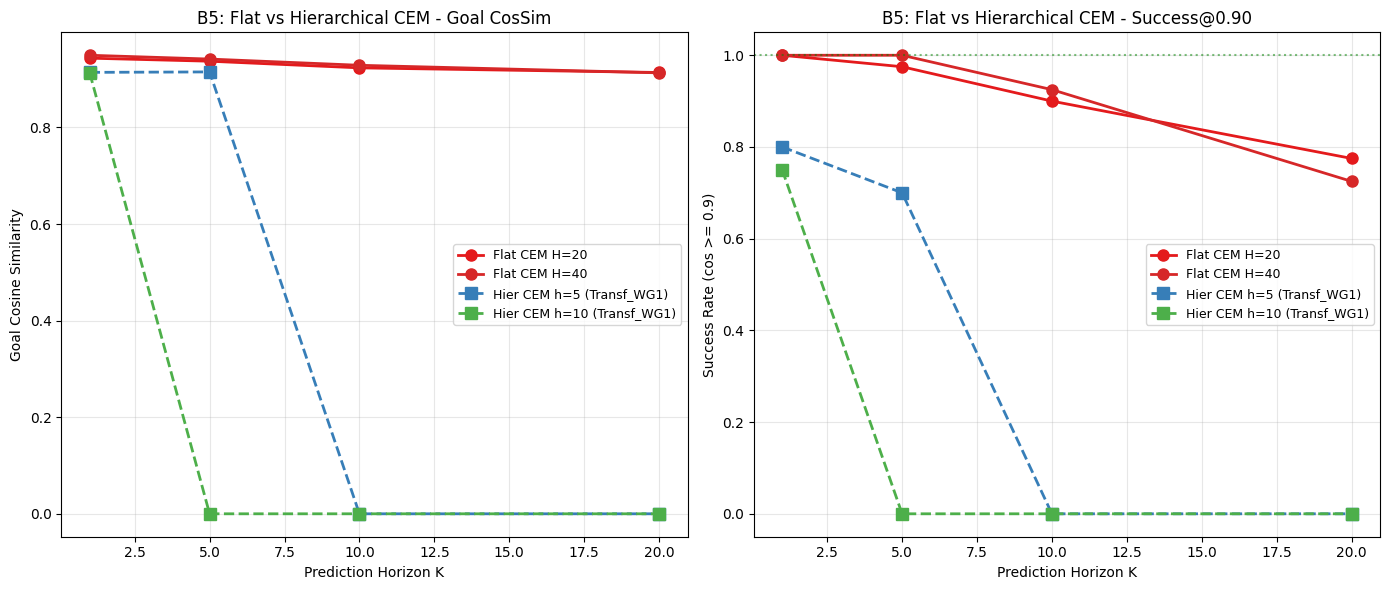

In [ ]:
# Plot B5: Flat vs Hierarchical CEM Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for Hi, H in enumerate(cfg.flat_H_values):
    flat_cos = [flat_cem_results.get(f'flat_K{k}_H{H}', {}).get('goal_cos', 0) for k in cfg.K_values]
    ax.plot(cfg.K_values, flat_cos, 'o-', linewidth=2, markersize=8,
            label=f'Flat CEM H={H}', color=['#e41a1c', '#d62728'][Hi])

for h in cfg.hier_h_values:
    key_pfx = f'hier_K{{}}_h{h}_{best_sg_key}_weighted'
    hier_cos = [hier_cem_results.get(key_pfx.format(k), {}).get('goal_cos', 0) for k in cfg.K_values]
    ax.plot(cfg.K_values, hier_cos, 's--', linewidth=2, markersize=8,
            label=f'Hier CEM h={h} ({best_sg_key})',
            color=['#377eb8', '#4daf4a'][cfg.hier_h_values.index(h)])

ax.set_xlabel('Prediction Horizon K')
ax.set_ylabel('Goal Cosine Similarity')
ax.set_title('B5: Flat vs Hierarchical CEM - Goal CosSim')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for Hi, H in enumerate(cfg.flat_H_values):
    flat_sr = [flat_cem_results.get(f'flat_K{k}_H{H}', {}).get('success_rate', 0) for k in cfg.K_values]
    ax.plot(cfg.K_values, flat_sr, 'o-', linewidth=2, markersize=8,
            label=f'Flat CEM H={H}', color=['#e41a1c', '#d62728'][Hi])

for h in cfg.hier_h_values:
    key_pfx = f'hier_K{{}}_h{h}_{best_sg_key}_weighted'
    hier_sr = [hier_cem_results.get(key_pfx.format(k), {}).get('success_rate', 0) for k in cfg.K_values]
    ax.plot(cfg.K_values, hier_sr, 's--', linewidth=2, markersize=8,
            label=f'Hier CEM h={h} ({best_sg_key})',
            color=['#377eb8', '#4daf4a'][cfg.hier_h_values.index(h)])

ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.5)
ax.set_xlabel('Prediction Horizon K')
ax.set_ylabel(f'Success Rate (cos >= {cfg.success_threshold})')
ax.set_title(f'B5: Flat vs Hierarchical CEM - Success@{cfg.success_threshold:.2f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b5_flat_vs_hier_cem.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# B5 Summary table
print(f'\n{"="*80}')
print('B5: Flat vs Hierarchical CEM - Summary')
print(f'{"="*80}')
print(f'\n{"Method":<35}{"K":<6}{"H/h":<8}{"Goal Cos":<12}{"Success@{:d}":<12}'.format(int(cfg.success_threshold*100)))
print('-' * 73)
for K in cfg.K_values:
    for H in cfg.flat_H_values:
        r = flat_cem_results.get(f'flat_K{K}_H{H}', {})
        print(f'{"Flat CEM":<35}{K:<6}{H:<8}{r.get("goal_cos", 0):<12.4f}{r.get("success_rate", 0):<12.3f}')
for h in cfg.hier_h_values:
    for K in cfg.K_values:
        key = f'hier_K{K}_h{h}_{best_sg_key}_weighted'
        r = hier_cem_results.get(key, {})
        print(f'{"Hier CEM (fixed-h, best sg):":<35}{K:<6}{h:<8}{r.get("goal_cos", 0):<12.4f}{r.get("success_rate", 0):<12.3f}')


B5: Flat vs Hierarchical CEM - Summary

Method                             K     H/h     Goal Cos    Success@90
-------------------------------------------------------------------------
Flat CEM                           1     20      0.9435      1.000       
Flat CEM                           1     40      0.9495      1.000       
Flat CEM                           5     20      0.9372      0.975       
Flat CEM                           5     40      0.9416      1.000       
Flat CEM                           10    20      0.9234      0.900       
Flat CEM                           10    40      0.9287      0.925       
Flat CEM                           20    20      0.9138      0.775       
Flat CEM                           20    40      0.9131      0.725       
Hier CEM (fixed-h, best sg):       1     5       0.9141      0.800       
Hier CEM (fixed-h, best sg):       5     5       0.9150      0.700       
Hier CEM (fixed-h, best sg):       10    5       0.0000      0.000       

## Section 8: B6 - Hierarchical CEM Ablations

Ablation: subgoal predictor type (MLP vs Transformer) effect on CEM performance at K=1.

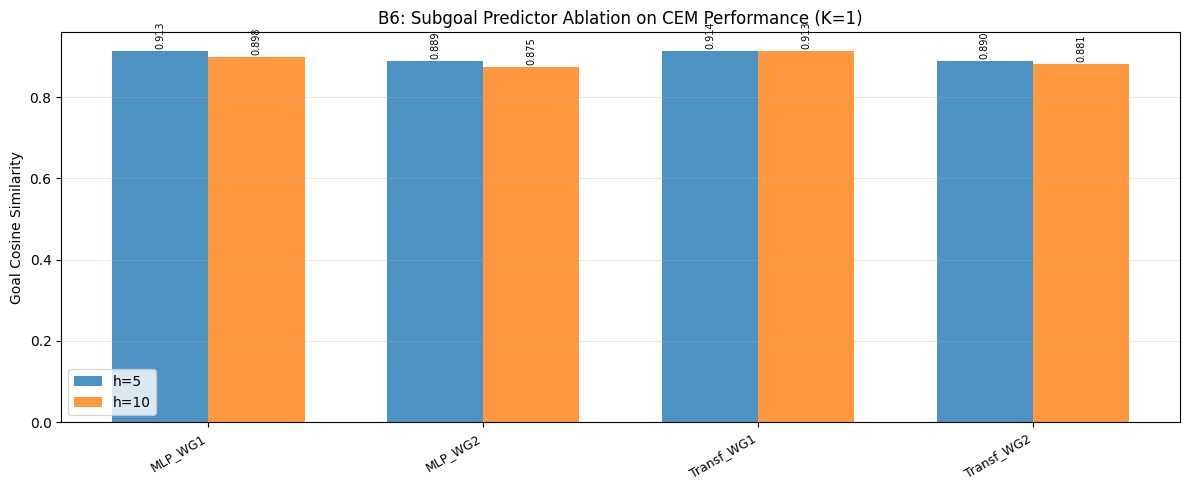


SG Predictor  h=5           h=10          
------------------------------------------
MLP_WG1       0.9129        0.8980        
MLP_WG2       0.8887        0.8745        
Transf_WG1    0.9141        0.9127        
Transf_WG2    0.8903        0.8810        


In [ ]:
# Plot B6: Subgoal predictor type + h ablation on CEM at K=1
fig, ax = plt.subplots(figsize=(12, 5))

K_eval = 1
sorted_sg_keys = sorted(sg_results.keys())
x = np.arange(len(sorted_sg_keys))
width = 0.35

for hi, h in enumerate(cfg.hier_h_values):
    cos_vals_h = [hier_cem_results.get(f'hier_K{K_eval}_h{h}_{k}_weighted', {}).get('goal_cos', 0) for k in sorted_sg_keys]
    bars = ax.bar(x + hi * width, cos_vals_h, width, label=f'h={h}', alpha=0.8)
    for bar, val in zip(bars, cos_vals_h):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x + width/2)
ax.set_xticklabels(sorted_sg_keys, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Goal Cosine Similarity')
ax.set_title(f'B6: Subgoal Predictor Ablation on CEM Performance (K={K_eval})')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b6_cem_ablations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"SG Predictor":<14}{"h=5":<14}{"h=10":<14}')
print('-' * 42)
for k in sorted_sg_keys:
    vals = [hier_cem_results.get(f'hier_K{K_eval}_h{h}_{k}_weighted', {}).get('goal_cos', 0) for h in cfg.hier_h_values]
    print(f'{k:<14}{vals[0]:<14.4f}{vals[1]:<14.4f}')

## Section 9: Summary & Save All

In [ ]:
print('=' * 70)
print('MODULE B: HIERARCHICAL PLANNING - COMPLETE SUMMARY')
print('=' * 70)

print(f'\n{"=" * 60}')
print('B1: Subgoal Extraction')
print(f'  Episodes: {len(train_sg_local)}')
print(f'  Total subgoals: {sum(sg_counts)}')
print(f'  Mean subgoals/ep: {np.mean(sg_counts):.2f}')

print(f'\n{"=" * 60}')
print('B3: Subgoal Predictor')
for k in sorted(sg_results.keys()):
    r = sg_results[k]
    print(f'  {k}: best_cos={r["best_cos"]:.4f}')
print(f'  Best: {best_sg_key}')

print(f'\n{"=" * 60}')
print('B5: Flat CEM')
for K in cfg.K_values:
    for H in cfg.flat_H_values:
        r = flat_cem_results.get(f'flat_K{K}_H{H}', {})
        print(f'  K={K:2d}, H={H:2d}: goal_cos={r.get("goal_cos", 0):.4f}, success={r.get("success_rate", 0):.3f}')

print(f'\n{"=" * 60}')
print('B5: Hierarchical CEM (best subgoal predictor)')
for h in cfg.hier_h_values:
    for K in cfg.K_values:
        key = f'hier_K{K}_h{h}_{best_sg_key}_weighted'
        r = hier_cem_results.get(key, {})
        print(f'  K={K:2d}, h={h:2d}: goal_cos={r.get("goal_cos", 0):.4f}, success={r.get("success_rate", 0):.3f}')

print(f'\n{"=" * 70}')
print(f'Plots: b2_subgoal_visualization.png, b3_subgoal_predictor.png')
print(f'       b5_flat_vs_hier_cem.png, b6_cem_ablations.png')
print('Module B complete!')

MODULE B: HIERARCHICAL PLANNING - COMPLETE SUMMARY

B1: Subgoal Extraction
  Episodes: 160
  Total subgoals: 324
  Mean subgoals/ep: 2.02

B3: Subgoal Predictor
  MLP_WG1: best_cos=0.4415
  MLP_WG2: best_cos=-1.0000
  Transf_WG1: best_cos=0.8767
  Transf_WG2: best_cos=-1.0000
  Best: Transf_WG1

B5: Flat CEM
  K= 1, H=20: goal_cos=0.9435, success=1.000
  K= 1, H=40: goal_cos=0.9495, success=1.000
  K= 5, H=20: goal_cos=0.9372, success=0.975
  K= 5, H=40: goal_cos=0.9416, success=1.000
  K=10, H=20: goal_cos=0.9234, success=0.900
  K=10, H=40: goal_cos=0.9287, success=0.925
  K=20, H=20: goal_cos=0.9138, success=0.775
  K=20, H=40: goal_cos=0.9131, success=0.725

B5: Hierarchical CEM (best subgoal predictor)
  K= 1, h= 5: goal_cos=0.9141, success=0.800
  K= 5, h= 5: goal_cos=0.9150, success=0.700
  K=10, h= 5: goal_cos=0.0000, success=0.000
  K=20, h= 5: goal_cos=0.0000, success=0.000
  K= 1, h=10: goal_cos=0.9127, success=0.750
  K= 5, h=10: goal_cos=0.0000, success=0.000
  K=10, h=10:

In [ ]:
# Save comprehensive results for Module D
torch.save({
    'sg_results': {k: {'val_cos': v['val_cos'], 'best_cos': v['best_cos'],
                       'WG': v['WG'], 'arch': v['arch']}
                    for k, v in sg_results.items()},
    'flat_cem_results': flat_cem_results,
    'hier_cem_results': hier_cem_results,
    'best_sg_key': best_sg_key,
    'sg_counts': sg_counts,
    'n_train_episodes': cfg.n_train_episodes,
    'config': vars(cfg),
}, OUTPUT_DIR / 'module_b_results.pt')
print('Module B results saved to outputs/module_b_results.pt')

Module B results saved to outputs/module_b_results.pt
